EfficientNetV2 hit a strong balance at launch and still holds up. It fine-tunes efficiently on small to mid-sized datasets from pretrained weights and generalizes well. Production teams like it because you don’t need large GPUs to fine-tune, yet you get strong accuracy.

It’s a natural fit for transfer learning: grab a pretrained checkpoint, adjust the final layers, and you’re ready. Common in on-device retail product recognition and defect detection, where cost and latency matter.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import transforms, models, datasets
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = 'datasets'
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
EPOCHS = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs('models', exist_ok=True)

# 1. Define distinct transforms
val_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15), # Add slight rotations
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Add slight color variations
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15), # Add slight rotations
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Add slight color variations
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [2]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.25):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, inputs, targets):
        # standard cross entropy
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        # pt is the probability of the true class
        pt = torch.exp(-ce_loss)
        # focal loss formula
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

In [3]:
# 2. Load the dataset twice to apply different transforms
full_dataset_train = datasets.ImageFolder(DATA_DIR, transform=train_transform)
full_dataset_eval = datasets.ImageFolder(DATA_DIR, transform=val_transform)

class_names = full_dataset_train.classes
num_classes = len(class_names)
print(f"EfficientNetV2 Pipeline | Classes: {num_classes} | Device: {device}")

EfficientNetV2 Pipeline | Classes: 7 | Device: cuda


In [4]:
# 3. Programmatic Split (80% Train, 10% Val, 10% Test)
total_size = len(full_dataset_train)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

# CRITICAL: Use the exact same seed (42) as Streamlit to prevent data leakage!
generator = torch.Generator().manual_seed(42)

train_idx, val_idx, test_idx = random_split(
    range(total_size), 
    [train_size, val_size, test_size], 
    generator=generator
)

# Create Subsets
train_data = Subset(full_dataset_train, train_idx.indices)
val_data = Subset(full_dataset_eval, val_idx.indices)
test_data = Subset(full_dataset_eval, test_idx.indices)

print(f"Data Split: {len(train_data)} Train | {len(val_data)} Val | {len(test_data)} Test")

Data Split: 25957 Train | 3244 Val | 3246 Test


In [5]:
# 4. DataLoaders
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=8, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=8)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=8)

print("GPU Active:", torch.cuda.is_available())

GPU Active: True


In [6]:
from tqdm.auto import tqdm

# ==========================================
# MODEL SETUP
# ==========================================
model = models.efficientnet_v2_s(pretrained=True)

# Replace head with Dropout for overfitting protection
num_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Flatten(),
    nn.BatchNorm1d(num_features),
    
    nn.Linear(num_features, 512),
    nn.LeakyReLU(negative_slope=0.3), # Keras default is 0.3
    nn.BatchNorm1d(512),
    nn.Dropout(0.2),
    
    nn.Linear(512, 256),
    nn.LeakyReLU(negative_slope=0.3),
    nn.BatchNorm1d(256),
    nn.Dropout(0.1),
    
    nn.Linear(256, 128),
    nn.LeakyReLU(negative_slope=0.3),
    nn.BatchNorm1d(128),
    
    nn.Linear(128, num_classes)
)

# Unfreeze strategy: Freeze blocks 0-3, unfreeze 4-7
for param in model.features[:4].parameters():
    param.requires_grad = False
for param in model.features[4:].parameters():
    param.requires_grad = True

model = model.to(device)

# ==========================================
# OPTIMIZER & LOSS
# ==========================================
criterion = FocalLoss(gamma=2.0, alpha=0.25)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), 
                        lr=LEARNING_RATE, 
                        weight_decay=LEARNING_RATE / EPOCHS)

In [7]:
# ==========================================
# THE TRAINING LOOP
# ==========================================
best_acc = 0.0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]", unit="batch")
    for inputs, labels in train_pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        train_pbar.set_postfix(loss=f"{running_loss/total:.4f}", acc=f"{100.*correct/total:.2f}%")
        
    train_loss = running_loss / len(train_data)
    train_acc = 100. * correct / total
    
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]", unit="batch", leave=False)
    
    with torch.no_grad():
        for inputs, labels in val_pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            val_pbar.set_postfix(loss=f"{val_loss/val_total:.4f}", acc=f"{100.*val_correct/val_total:.2f}%")
            
    val_loss = val_loss / len(val_data)
    val_acc = 100. * val_correct / val_total
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    print(f"--> Epoch {epoch+1} Summary | Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")
    
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'models/efficientnetv2_best.pth')
        print("  --> Saved best model!")

Epoch 1/10 [Train]: 100%|██████████| 406/406 [02:28<00:00,  2.73batch/s, acc=61.34%, loss=0.1653]


--> Epoch 1 Summary | Train Loss: 0.1653, Acc: 61.34% | Val Loss: 0.0935, Acc: 75.52%
  --> Saved best model!


Epoch 2/10 [Train]: 100%|██████████| 406/406 [02:28<00:00,  2.73batch/s, acc=78.31%, loss=0.0812]


--> Epoch 2 Summary | Train Loss: 0.0812, Acc: 78.31% | Val Loss: 0.0756, Acc: 80.36%
  --> Saved best model!


Epoch 3/10 [Train]: 100%|██████████| 406/406 [02:25<00:00,  2.79batch/s, acc=84.86%, loss=0.0504]


...

--> Epoch 8 Summary | Train Loss: 0.0108, Acc: 95.95% | Val Loss: 0.0701, Acc: 84.28%


Epoch 9/10 [Train]: 100%|██████████| 406/406 [02:31<00:00,  2.68batch/s, acc=96.49%, loss=0.0096]


--> Epoch 9 Summary | Train Loss: 0.0096, Acc: 96.49% | Val Loss: 0.0725, Acc: 84.37%


Epoch 10/10 [Train]: 100%|██████████| 406/406 [02:29<00:00,  2.72batch/s, acc=96.63%, loss=0.0091]
                                                                                              

--> Epoch 10 Summary | Train Loss: 0.0091, Acc: 96.63% | Val Loss: 0.0722, Acc: 84.00%


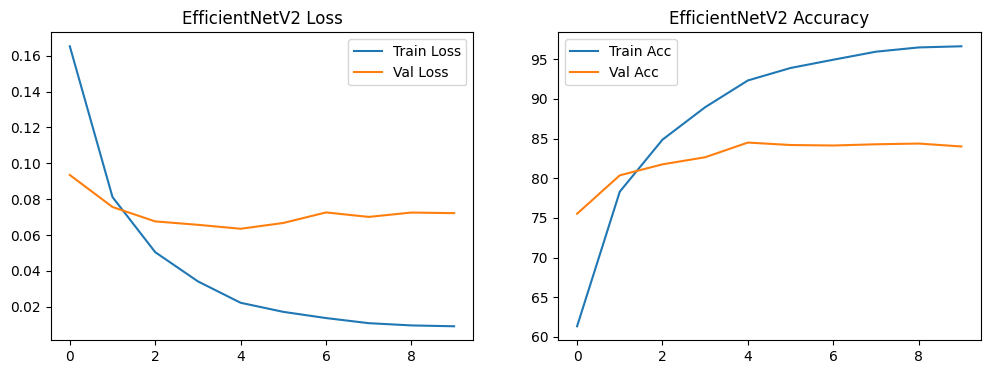


--- Test Set Results ---
               precision    recall  f1-score   support

  Art Nouveau       0.88      0.80      0.84       301
      Baroque       0.83      0.85      0.84       520
Expressionism       0.86      0.89      0.87       244
Neoclassicism       0.88      0.80      0.84       336
      Realism       0.79      0.83      0.81       512
  Renaissance       0.87      0.88      0.88       648
  Romanticism       0.80      0.82      0.81       685

     accuracy                           0.84      3246
    macro avg       0.85      0.84      0.84      3246
 weighted avg       0.84      0.84      0.84      3246



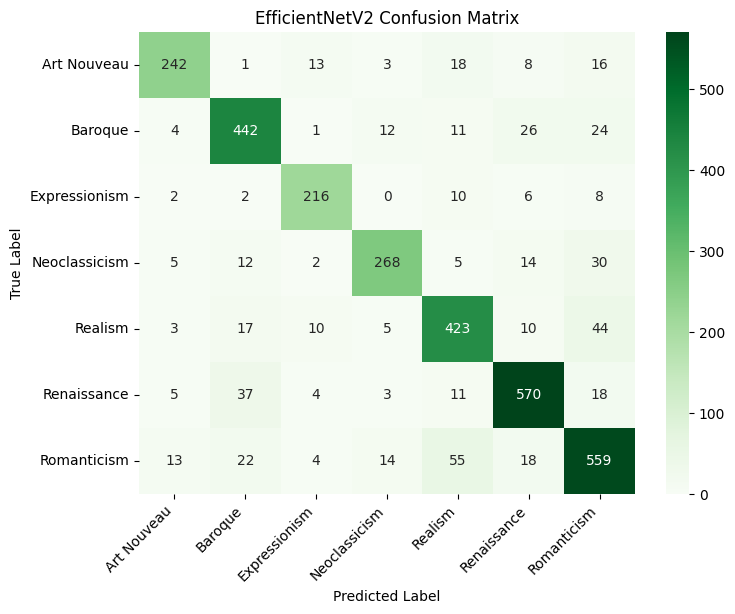

In [8]:
# 7. Evaluation & Visualization
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('EfficientNetV2 Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('EfficientNetV2 Accuracy')
plt.legend()
plt.show()

# Load best model for testing
model.load_state_dict(torch.load('models/efficientnetv2_best.pth'))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        all_preds.extend(outputs.max(1)[1].cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n--- Test Set Results ---")
print(classification_report(all_labels, all_preds, target_names=class_names))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(all_labels, all_preds), annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title('EfficientNetV2 Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.show()


--- Dataset Class Distribution ---
    Art Style
  Art Nouveau
      Baroque
Expressionism
Neoclassicism
      Realism
  Renaissance
  Romanticism
        TOTAL
----------------------------------

Calculating Confidence and Recall on Test Set...


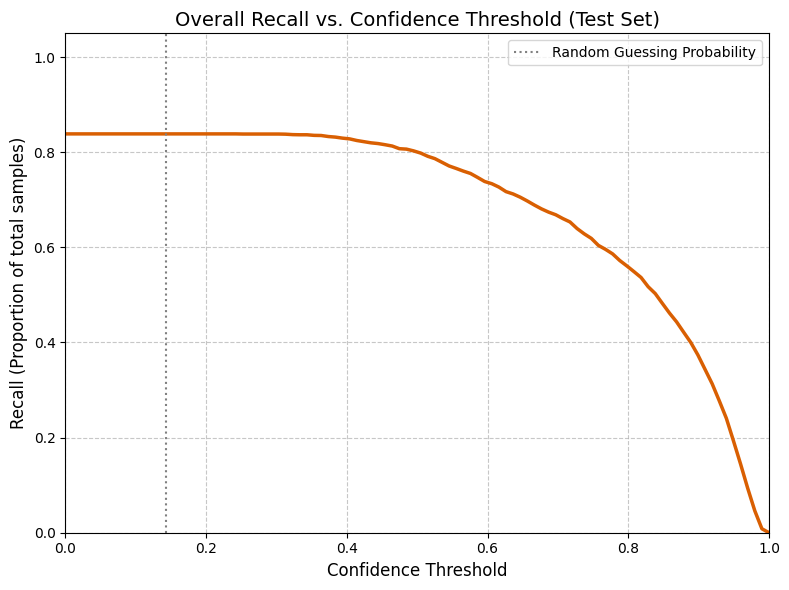

In [9]:
import pandas as pd
import numpy as np
import torch.nn.functional as F

# ==========================================
# 1. Class Distribution Table
# ==========================================
from collections import Counter

def get_counts(dataset):
    # ImageFolder stores the integer labels in the .targets attribute
    counts = Counter(dataset.targets)
    return [counts[i] for i in range(len(dataset.classes))]

# Create a DataFrame for clean formatting
dist_df = pd.DataFrame({
    'Art Style': class_names
})

# Add a Total row at the bottom
dist_df.loc['Total'] = dist_df.sum(numeric_only=True)
dist_df.at['Total', 'Art Style'] = 'TOTAL'

print("\n--- Dataset Class Distribution ---")
print(dist_df.to_string(index=False))
print("-" * 34)


# ==========================================
# 2. Recall vs. Confidence Threshold Curve
# ==========================================
print("\nCalculating Confidence and Recall on Test Set...")

# Ensure model is in evaluation mode
model.eval()
all_probs = []
all_labels = []

# Extract probabilities and labels from the Test Set
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        
        # Apply softmax to get true probabilities (0.0 to 1.0)
        probs = F.softmax(outputs, dim=1)
        
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

# Flatten the lists into single numpy arrays
all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)

# For each image, find the highest probability and its corresponding class prediction
confidences = np.max(all_probs, axis=1)
predictions = np.argmax(all_probs, axis=1)

# Test 100 different confidence thresholds from 0% to 100%
thresholds = np.linspace(0.0, 1.0, 100)
overall_recalls = []

for t in thresholds:
    # A prediction is a True Positive only if it is correct AND the model's confidence is >= t
    correct_and_confident = np.sum((predictions == all_labels) & (confidences >= t))
    
    # Recall = (Correct & Confident) / Total actual images
    recall = correct_and_confident / len(all_labels)
    overall_recalls.append(recall)

# Plot the curve
plt.figure(figsize=(8, 6))
plt.plot(thresholds, overall_recalls, linewidth=2.5, color='#d95f02')

# Formatting the plot
plt.title('Overall Recall vs. Confidence Threshold (Test Set)', fontsize=14)
plt.xlabel('Confidence Threshold', fontsize=12)
plt.ylabel('Recall (Proportion of total samples)', fontsize=12)
plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.05)
plt.grid(True, linestyle='--', alpha=0.7)

# Add a vertical line marking the baseline (model makes a prediction no matter what)
plt.axvline(x=1/num_classes, color='grey', linestyle=':', label='Random Guessing Probability')
plt.legend()

plt.tight_layout()
plt.show()